### Modeling

 * In this section we will use several regression models to predict a player's fantasy value based on his average season statistics. Since fantasy value is a continuous target (z-score across categories), regression is a natural choice. We experiment with both linear and non-linear approaches to balance interpretability and predictive power.
---
 * **Linear Regression** – A statistical and machine learning method for finding the linear relationship between a continuous dependent variable and one or more independent variables. It serves as our baseline model because of its simplicity and interpretability.
 * **OLS by statsmodels** - As linear regression this model works to based on Ordinary Least Squares but in differ from the scikit-learn Linear Regression the models focuses Explanatory analysis - understanding the underlying relationships between variables and their statistical significance.
 * **Ridge Regression** – A variant of linear regression that adds an L2 penalty to shrink coefficients of correlated features. This helps reduce overfitting and improve stability when predictors are highly collinear (common in basketball stats such as PTS, USG%, and FGA).
 * **PCA + Linear Regression** – Principal Component Analysis (PCA) is first applied to reduce dimensionality and remove multicollinearity among features while retaining most of the variance (95%). A linear regression model is then trained on the compressed feature space, allowing us to capture the main signal with fewer dimensions.
 * **Random Forest Regressor** – An ensemble of decision trees where each tree is trained on a random subset of data and features. Random Forests can capture non-linear relationships and feature interactions, making them useful when the relationship between raw stats and fantasy value is not strictly linear.
 * **XGBoost Regressor** – A gradient boosting method that builds decision trees sequentially, where each tree corrects errors from the previous ones. XGBoost often outperforms Random Forest by focusing on difficult-to-predict cases and is widely used in applied machine learning competitions due to its high accuracy.

Because of linear models limitations to handle with null values, we created a copy of the data frame where all NaN (located only on _roll and _delta columns) will get the value -999.

---

Our modeling strategy combines different types of features:
 * **Quantitative features:**
    <u>Box score statistics:</u> traditional per-game averages such as points, rebounds, assists, steals, blocks, turnovers, and shooting percentages.
    <u>Durability metrics:</u> games played and minutes per game, since fantasy value is strongly affected by availability.
    <u>Rolling averages and deltas:</u> aggregated features from the previous two seasons to capture both consistency and trends in player development.
 * **Qualitative feature:**
   <u>Demographics:</u> player age and position, as younger players often improve while older players may decline, and positions reflect different statistical profiles.

We then compare the model's predictive accuracy using MAE, RMSE, and R².

---
Feature engineering for model's performance:
 * **Age:** Age often has a nonlinear relationship: Players improve until ~27–29, then decline. A quadratic term captures that curve. Instead of the model assuming “+1 year = always better/worse,” it can learn the “arc” of improvement then decline.
 * **Per 36 and totals:** Creating them to normalize the model's performance. We use them only for stats where per-minute scaling makes sense (PTS, REB, AST, STL, BLK) and not for stats as percetages.

---

Summary of OLS and the difference between the two models:
* The core difference between statsmodels.OLS and scikit-learn.LinearRegression lies in their primary objective and the information they provide.
* **statsmodels.OLS** is built for statistical inference and explanation. Its purpose is to help you understand the relationship between variables and the statistical significance of their coefficients. It provides a comprehensive summary table with statistical details like p-values, standard errors, and confidence intervals.It does not automatically add an intercept, forcing the user to explicitly add one with sm.add_constant().It may produce a better predictive model in cases where its slightly different implementation details or numerical procedures are a better fit for the specific characteristics of your data.
* **scikit-learn.LinearRegression** is built for predictive modeling and machine learning workflows. It prioritizes ease of use, speed, and integration into larger pipelines for tasks like cross-validation and hyperparameter tuning.Its output is more concise, focusing on coefficients and basic performance scores like \(R^{2}\). It does not provide detailed statistical summaries with p-values.It includes an intercept by default, which can sometimes lead to different initial results compared to statsmodels if not handled correctly.



In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
import joblib
import sys
sys.path.append(os.getcwd())

import utils


print("✅ All libraries are working!")

✅ All libraries are working!


#### There are few functions in the utils file that will help us to do the following assignments:
- evaluate_baseline function - Will calculate the errors of the baseline which is determined as the value of a player's last season.
- preprocess_linear_features function - A preprocessor designated for the linear models (which can't get NaN values).
- preprocess_features function - A general preprocessor for non-linear models.

In [3]:
df = pd.read_pickle("../data/processed_data.pkl")
cats_df = pd.read_pickle("../data/cats.pkl")
cats = cats_df.set_index("Category")["Column"].to_dict()

In [4]:
df = df.sort_values(by=["PLAYER_NAME", "SEASON_ID"]).reset_index(drop=True)
# List of stats to use for rolling + delta
stats = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'FG3M', 'FG%', 'FT%', 'TOV', 'GP', 'MIN']
# Calculating rolling averages and delta
for col in stats:
    df[f"{col}_roll2"] = df.groupby("PLAYER_NAME")[col].transform(lambda x: x.rolling(2, min_periods=1).mean().shift())
    df[f"{col}_delta"] = df.groupby("PLAYER_NAME")[col].diff()
#print(df.loc[:,"PTS_roll2":].head(8))
# Target variable: fantasy z-score (you can change if named differently), shift(-1) moves values up so each player get his traget score for the model
df["next_fantasy_z_9cat"] = df.groupby("PLAYER_NAME")["fantasy_z_9cat"].shift(-1)
for col in cats:
    df[f"next_z_{col}"] = df.groupby("PLAYER_NAME")[f"z_{col}"].shift(-1)
# delta target = next season - current season
df["delta_fantasy"] = df["next_fantasy_z_9cat"] - df["fantasy_z_9cat"]
#print(df.loc[: , :'delta_fantasy'].head())

In [5]:
df_linear = utils.preprocess_linear_features(df) #filling NaN with -999, creating an has_history flag
#print(df_linear.info())
df_linear = utils.preprocess_features(df_linear) #adding per36 stats and age squared
df = utils.preprocess_features(df)

#print(df_linear.loc[: , :'delta_fantasy'].head())

# baseline (last season) is simply the current fantasy_z_9cat value
baseline_results = utils.evaluate_baseline(df)

print("Baseline stats (last season → current season):")
print(f"MAE: {baseline_results['MAE']:.3f}")
print(f"RMSE: {baseline_results['RMSE']:.3f}")
print(f"R-squared: {baseline_results['R-squared']:.3f}")
print(f"Adjusted R-squared: {baseline_results['Adjusted R-squared']:.3f}")

Baseline stats (last season → current season):
MAE: 1.857
RMSE: 2.399
R-squared: 0.669
Adjusted R-squared: 0.649


In [6]:
# Target = delta in fantasy z-scor
df["target_delta"] = df["next_fantasy_z_9cat"] - df["fantasy_z_9cat"]
df_linear["target_delta"] = df_linear["next_fantasy_z_9cat"] - df_linear["fantasy_z_9cat"]

# --- Features we’ll use ---
base_features = ["PTS", "REB", "AST", "STL", "BLK", "TOV", "FG%", "FT%", "FG3M"]
trend_features = [c for c in df.columns if "_roll2" in c or "_delta" in c or "_per36" in c]
durability = ["GP", "MIN"]
demographics = ["AGE", "POS"]

feature_cols = base_features + trend_features + demographics
feature_cols.remove("target_delta")
#print(feature_cols)

# Add age^2
df["AGE_squared"] = df["PLAYER_AGE"] ** 2
df_linear["AGE_squared"] = df_linear["PLAYER_AGE"] ** 2

feature_cols.append("AGE_squared")
feature_cols.remove("AGE")

# Train and test data = up to 2023-24, Prediction data = 2024-25
train_val = df[df["SEASON_ID"] < "2024-25"]   # 2020-21 → 2023-24
linear_train_val = df_linear[df_linear["SEASON_ID"] < "2024-25"]
predict_only = df_linear[df_linear["SEASON_ID"] == "2024-25"]  # 2024-25
#train_val.to_csv("train_set.csv", index = False)

X = train_val[feature_cols]
y = train_val["next_fantasy_z_9cat"]

# Example: hold out 2023-24 as test
train = train_val[train_val["SEASON_ID"] < "2023-24"].dropna(subset=["target_delta"])
linear_train = linear_train_val[linear_train_val["SEASON_ID"] < "2023-24"].dropna(subset=["target_delta"])
test = train_val[train_val["SEASON_ID"] == "2023-24"].dropna(subset=["target_delta"])
linear_test = linear_train_val[linear_train_val["SEASON_ID"] == "2023-24"].dropna(subset=["target_delta"])

linear_X_train, X_train, y_train = linear_train[feature_cols], train[feature_cols], train["next_fantasy_z_9cat"]
linear_X_test, X_test, y_test = linear_test[feature_cols] ,test[feature_cols], test["next_fantasy_z_9cat"]

prediction_df_features = predict_only[feature_cols]

# Sample weights (durability)
sample_weights = train["sample_weight_norm"].values

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Prediction shape:", prediction_df_features.shape)



Train shape: (1022, 39)
Test shape: (388, 39)
Prediction shape: (434, 39)


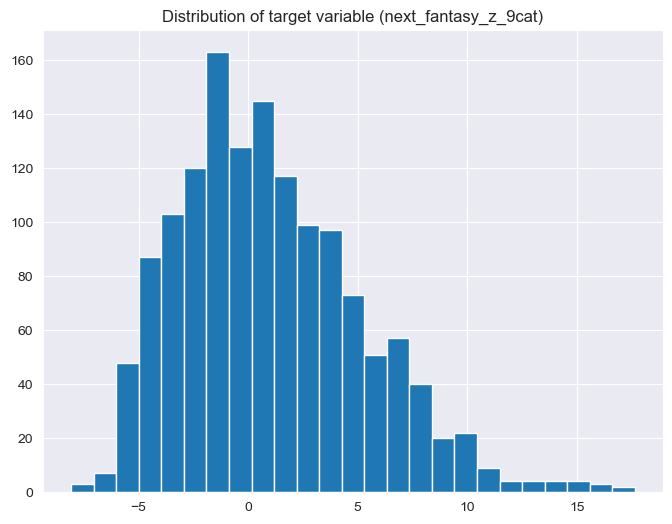

In [7]:
plt.figure(figsize =(8,6))
plt.hist(df["next_fantasy_z_9cat"], bins=25)
plt.grid(True)
plt.title("Distribution of target variable (next_fantasy_z_9cat)")
plt.show()

**The target variable follows a roughly normal distribution with a slight right skew, which satisfies the normality assumption required for OLS regression.**

In [8]:
#creating a preprocessor - one hot encoding and standard scaler for numeric features
position = ["POS"] if "POS" in X_train.columns else []
numeric = [c for c in X_train.columns if c not in position]
preprocessor = ColumnTransformer(transformers=[("pos", OneHotEncoder(drop="first"), position), ("num", StandardScaler(), numeric)])
results = {}
results["Baseline"] = baseline_results
fitted_models = {}

In [9]:
#linear regression
pipe_LR = Pipeline([('preprocessor', preprocessor),("LinearRegression", LinearRegression())])
pipe_LR.fit(linear_X_train, y_train, LinearRegression__sample_weight=sample_weights)
y_preds_LR = pipe_LR.predict(linear_X_test)
p_LR = len(pipe_LR.named_steps['preprocessor'].get_feature_names_out())
#print(evaluate(y_test, y_pred_delta_LR))

results["LinearRegression"] = utils.evaluate(y_test ,y_preds_LR, p_LR)
fitted_models["LinearRegression"] = pipe_LR

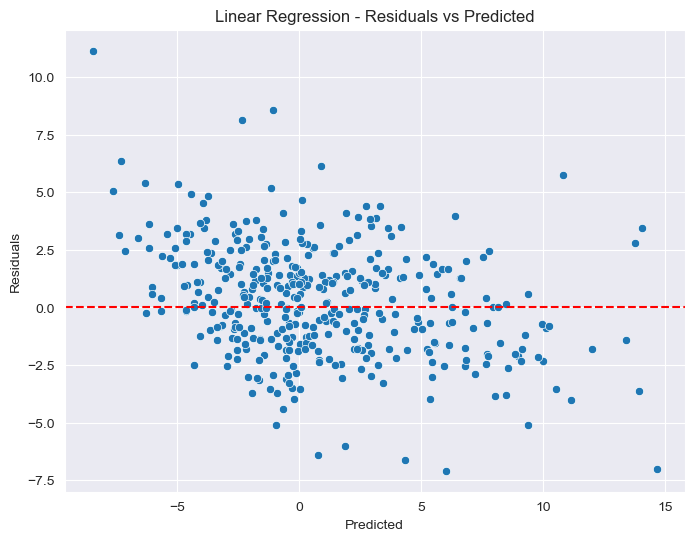

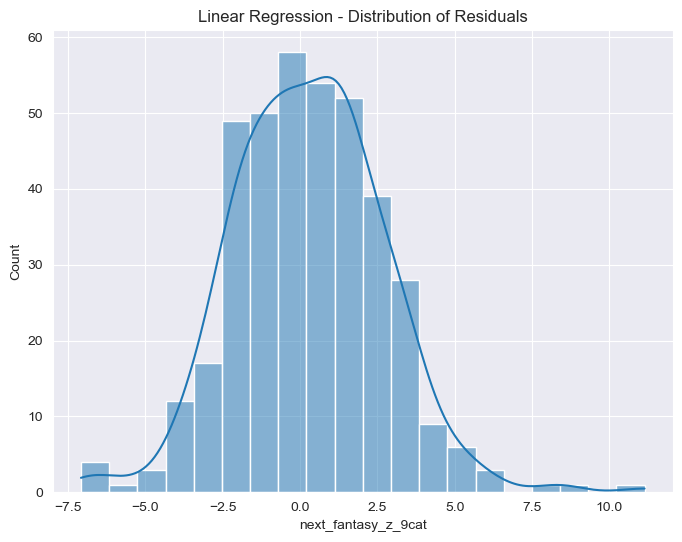

In [10]:
utils.plot_residaul_analysis(pipe_LR, "Linear Regression", linear_X_test, y_test)

In [11]:
#Ridge
pipe_R = Pipeline([('preprocessor', preprocessor),("Ridge", Ridge(alpha = 100))])
pipe_R.fit(linear_X_train, y_train, Ridge__sample_weight=sample_weights)
y_preds_R = pipe_R.predict(linear_X_test)
p_R = len(pipe_LR.named_steps['preprocessor'].get_feature_names_out())
#print(evaluate(y_test, y_pred_delta_R))

results["Ridge"] = utils.evaluate(y_test ,y_preds_R, p_R)
fitted_models["Ridge"] = pipe_R

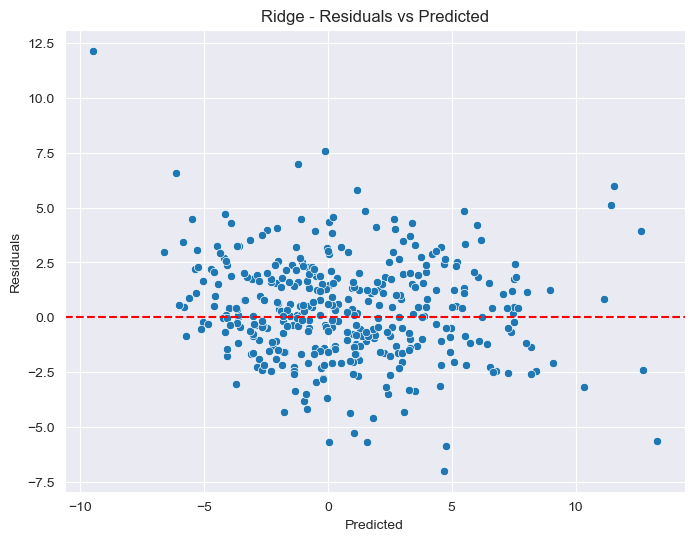

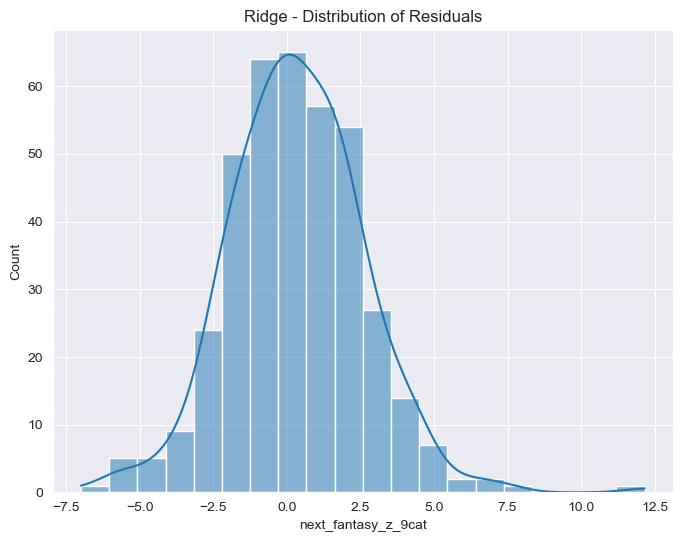

In [12]:
utils.plot_residaul_analysis(pipe_R, "Ridge", linear_X_test, y_test)

In [13]:
#PCA + Linear Regression - keeping more than 95% of the variance - play with number of components and the graph below to see the change between the number components
pca_pipe = Pipeline([('preprocessor', preprocessor),("pca", PCA(n_components=0.95, random_state=42)), ("LinearRegression", LinearRegression())])
pca_pipe.fit(linear_X_train, y_train, LinearRegression__sample_weight=sample_weights)
y_preds_pca = pca_pipe.predict(linear_X_test)
p_pca = len(pipe_LR.named_steps['preprocessor'].get_feature_names_out())
#print(evaluate(y_test, y_pred_delta_pca))

results["PCA + Linear Regression"] = utils.evaluate(y_test ,y_preds_pca, p_pca)
fitted_models["PCA + Linear Regression"] = pca_pipe

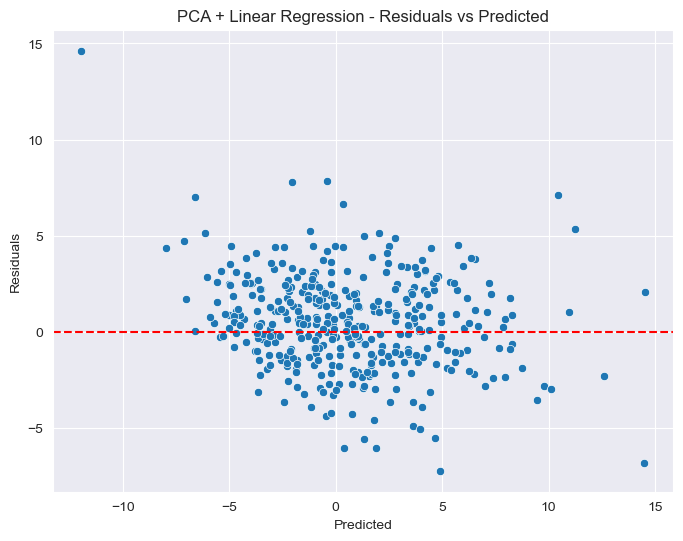

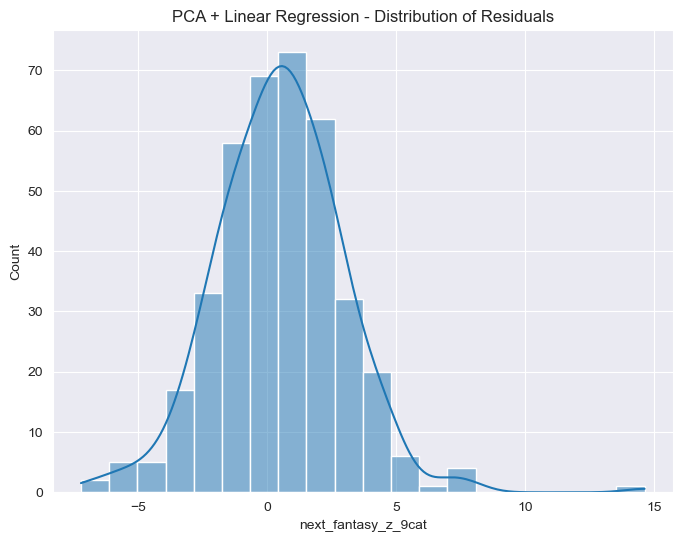

In [14]:
utils.plot_residaul_analysis(pca_pipe, "PCA + Linear Regression", linear_X_test, y_test)

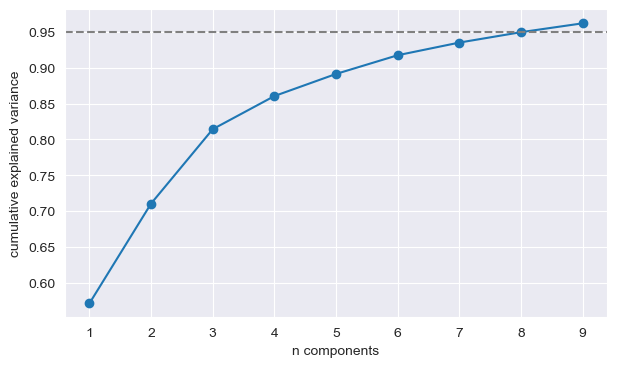

In [15]:
cum_var = np.cumsum(pca_pipe[1].explained_variance_ratio_)
plt.figure(figsize=(7,4))
plt.plot(np.arange(1,len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, color='grey', linestyle='--')
plt.xlabel("n components"); plt.ylabel("cumulative explained variance"); plt.grid(True)

In [16]:
#Random Forrest regressor
pipe_RF = Pipeline([('preprocessor', preprocessor),("RandomForest", RandomForestRegressor(n_estimators=300, random_state=42, max_depth=10))])
pipe_RF.fit(linear_X_train, y_train)
y_preds_RF = pipe_RF.predict(linear_X_test)
p_RF = len(pipe_LR.named_steps['preprocessor'].get_feature_names_out())
#print(evaluate(y_test, y_pred_delta_RF))

results["RandomForest"] = utils.evaluate(y_test ,y_preds_RF, p_RF)
fitted_models["RandomForest"] = pipe_RF

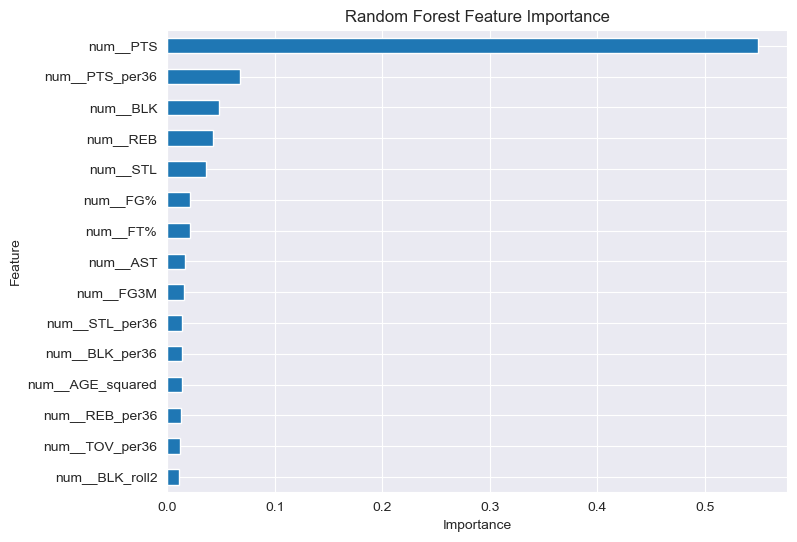

In [17]:
utils.plot_feature_importance(pipe_RF , feature_cols, "Random Forest Feature Importance")

In [18]:
#XGBoost
try:
    pipe_XG = Pipeline([('preprocessor', preprocessor),("XGBoost", XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42))])
    pipe_XG.fit(X_train, y_train, XGBoost__sample_weight=sample_weights)
    y_preds_XG = pipe_XG.predict(X_test)
    p_XG = len(pipe_LR.named_steps['preprocessor'].get_feature_names_out())
    #print(evaluate(y_test, y_pred_delta_XG))

    results["XGBoost"] = utils.evaluate(y_test ,y_preds_XG, p_XG)
    fitted_models["XGBoost"] = pipe_XG
except ImportError:
    print("⚠️ XGBoost not installed, skipping that model.")

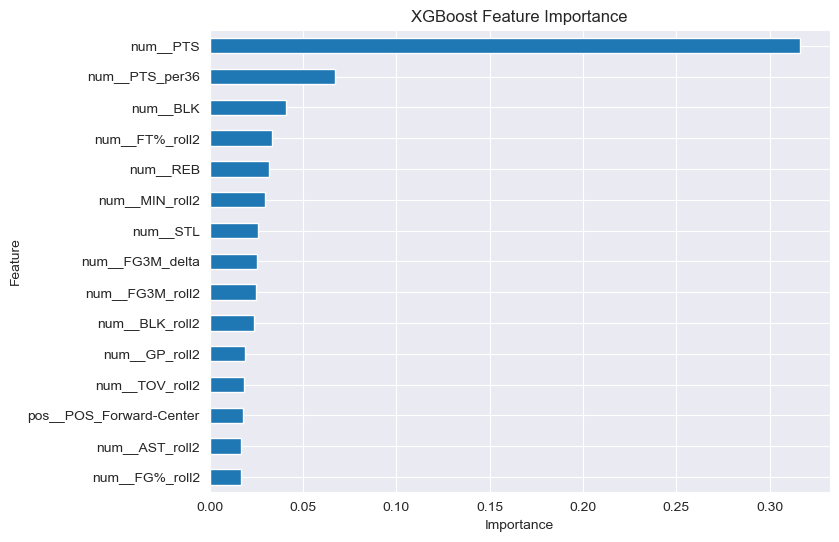

In [19]:
utils.plot_feature_importance(pipe_XG, feature_cols, "XGBoost Feature Importance")

**OLS by statmodels - I used backward elimination (backward_elimination_ols_named function in utils) to iteratively remove statistically insignificant features, reducing model complexity and multicollinearity.**

In [20]:
# OLS linear regression, every run omitting the feature with the highest P-value until all values are smaller than 0.05
X_train_arr = preprocessor.transform(linear_X_train)
X_train_df = pd.DataFrame(X_train_arr, columns=preprocessor.get_feature_names_out(), index=linear_X_train.index)

y = y_train

ols_model, final_features = utils.backward_elimination_ols_named(X_train_df, y , X_train_df.columns.tolist(), 0.05)

p_OLS = len(final_features)
preds_OLS = ols_model.fittedvalues
results["OLS"] = utils.evaluate(y ,preds_OLS, p_OLS)
fitted_models["OLS"] = ols_model
#print(ols_model.summary())

In [21]:
# OLS linear regression with PCA, doesn't omit any features
pca = PCA(n_components = 8, random_state=42) # 95% of the variance
X_pca = pca.fit_transform(X_train_df)
X_pca_df = pd.DataFrame(X_pca, columns=[f"PCA_{i}" for i in range(X_pca.shape[1])], index=X_train_df.index)

ols_PCA_model, final_features_pca = utils.backward_elimination_ols_named(X_pca_df, y , X_pca_df.columns.tolist(), 1)

p_ols_pca = len(final_features_pca)
preds_OLS_PCA = ols_PCA_model.fittedvalues
results["OLS_PCA"] = utils.evaluate(y ,preds_OLS_PCA, p_ols_pca)
fitted_models["OLS_PCA"] = ols_PCA_model

#print(ols_PCA_model.summary())

In [22]:
# Show results
results_df = pd.DataFrame(results).T.sort_values("R-squared", ascending = False)
styled_results = (
    results_df.style
    .format({"MAE": "{:.3f}", "R-squared": "{:.3f}", "RMSE":"{:.3f}", "Adjusted R-squared":"{:.3f}"})
    .highlight_min("MAE", color="#ABEBC6")
    .highlight_max("R-squared", color="#ABEBC6")
    .highlight_min("RMSE", color="#ABEBC6")
    .highlight_max("RMSE", color="#F5B7B1")
    .highlight_max("MAE", color = "#F5B7B1")
    .highlight_min("R-squared", color = "#F5B7B1")
    .highlight_max("Adjusted R-squared", color = "#ABEBC6")
    .highlight_min("Adjusted R-squared", color = "#F5B7B1")
)
display(styled_results)

print("Baseline stats (last season → current season):")
print(f"MAE: {baseline_results['MAE']:.3f}")
print(f"RMSE: {baseline_results['RMSE']:.3f}")
print(f"R-squared: {baseline_results['R-squared']:.3f}")
print(f"Adjusted R-squared: {baseline_results['Adjusted R-squared']:.3f}")


,MAE,RMSE,R-squared,Adjusted R-squared
OLS,1.750,2.237,0.714,0.709
RandomForest,1.816,2.294,0.692,0.655
XGBoost,1.801,2.318,0.686,0.647
Ridge,1.785,2.320,0.685,0.647
Baseline,1.857,2.399,0.669,0.649
LinearRegression,1.915,2.441,0.651,0.609
OLS_PCA,1.984,2.511,0.640,0.637
PCA + Linear Regression,1.934,2.528,0.626,0.580


Baseline stats (last season → current season):
MAE: 1.857
RMSE: 2.399
R-squared: 0.669
Adjusted R-squared: 0.649


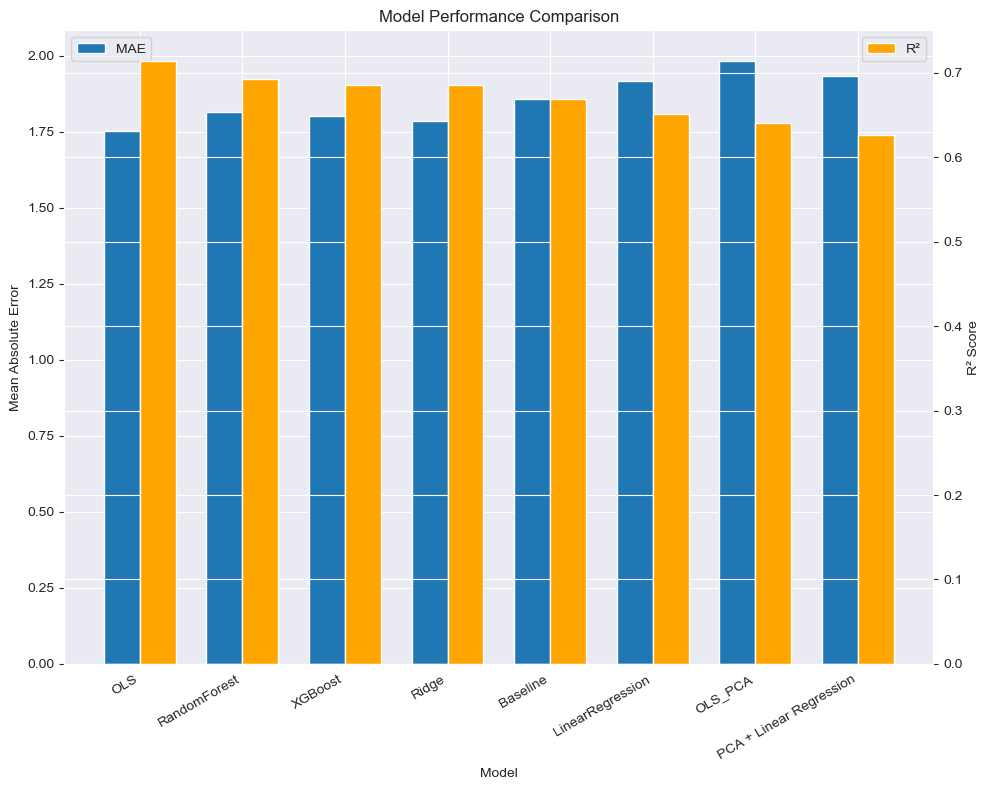

In [23]:
# Bar plot for MAE and R²
fig, ax1 = plt.subplots(figsize=(10,8))

results_df_plot = results_df.copy()
models_list = results_df_plot.index

x = np.arange(len(models_list))
width = 0.35

ax1.bar(x - width/2, results_df_plot["MAE"], width, label="MAE")
ax1.set_ylabel("Mean Absolute Error")
ax1.set_xlabel("Model")
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=30, ha="right")

# Add secondary axis for R²
ax2 = ax1.twinx()
ax2.bar(x + width/2, results_df_plot["R-squared"], width, color="orange", label="R²")
ax2.set_ylabel("R² Score")

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

## Modeling Conclusions

**OLS** is the clear best performer, while **PCA + Linear Regression** and **OLS\_PCA** performed poorly. Only **OLS** and the tree-based models (**XGBoost** and **Random Forest**) managed to outperform the **Baseline** in terms of R-squared, MAE and RMSE.

***

### 1. The Dominance of OLS and the Regression Paradox

The key takeaway is that **OLS (Ordinary Least Squares) is the best model** ($\text{MAE}=1.750, R^2=0.714$).

* **Strong Linear Relationship Confirmed:** The high $R^2$ value ($\mathbf{0.714}$) for OLS still confirms a **strong linear relationship** between the selected features and the target variable, `next_fantasy_z_9cat`.
* **The Paradox of Poor Linear Model Performance:** It is highly unusual for **Linear Regression** ($\text{MAE}=1.915, R^2=0.651$), **Ridge** ($\text{MAE}=1.813, R^2=0.674$), and the PCA-based models to perform worse than the **Baseline** ($\text{MAE}=1.857, R^2=0.669$).
    * **The Likely Culprit: Multicollinearity.** Your correlation matrix (image **image_cfeb8f.png**) shows **very strong correlations** between features, such as `PTS` vs. `TOV` ($-0.84$), `PTS` vs. `AST` ($0.70$), and `REB` vs. `BLK` ($0.64$). When using the full feature set, this **multicollinearity** can make the standard Linear Regression coefficients highly unstable and inflate their variance, leading to poor generalization (i.e., poor out-of-sample performance, resulting in the low $R^2$ and high $\text{MAE}$).
    * **Why OLS Excels:** The OLS model used here appears to have successfully applied a **feature selection** step (likely by dropping features with high p-values) which is the most effective strategy for this dataset. By dropping the redundant/unstable features, it successfully stabilized the model, leading to the best performance.
    * **Why Ridge Fails:** Ridge Regression is designed to handle multicollinearity by shrinking coefficients, but in this specific instance, the regularization penalty may have been too strong or the combination of highly correlated features was too complex for a standard Ridge approach to stabilize effectively without severely harming predictive power (resulting in $R^2=0.674$, only marginally better than the Baseline).

***

### 2. Failure of Dimensionality Reduction (PCA)

The **PCA-based models are the worst performers** ($\mathbf{R^2 \approx 0.63}$).

* **PCA + Linear Regression** and **OLS\_PCA** performed poorly, suggesting that simply transforming the features via **PCA destroyed some of the most critical predictive information**.
* PCA is a rotation that maximizes variance but does not account for the target variable. In this case, **feature selection (as done by OLS)** was far more effective than feature transformation (PCA) at dealing with the feature redundancy.

***

### 3. Tree Models Outperform Most Linear Models

The tree-based models, **XGBoost** ($\text{MAE}=1.801, R^2=0.686$) and **Random Forest** ($\text{MAE}=1.816, R^2=0.692$), both significantly **outperformed the standard Linear Regression and Ridge** models.

* This suggests that while the overall relationship is mostly linear, the tree-based models' ability to handle **feature interactions** and **multicollinearity implicitly** allowed them to stabilize better than the unstable linear models. They are robust alternatives to the highly tuned OLS model.

***

### 4. Robust Feature Importance

The feature importance plots for **Random Forest** and **XGBoost** (images **image_d03d68.png** and **image_d03d82.png**) consistently highlight **scoring ability** as the top predictor.

* `num_PTS` and `num_PTS_per36` are the **most important features by a substantial margin**. This is a highly stable finding across all model iterations and corroborates the strong correlation of `PTS` with the target variable ($0.88$).

***

### 5. Examination of Residuals

The residual plots (images **image_d03d4a.png**, **image_cfebaa.png**, and **image_cfebad.png**) offer important insights:

* **Residual Distribution:** The histogram (image **image_d03d4a.png**) shows the residuals for PCA + Linear Regression **approximate a normal distribution** centered around zero, which is a key assumption for linear models.
* **Homoscedasticity:** The **Linear Regression** and **Ridge** Residuals vs. Predicted plots (images **image_cfebaa.png** and **image_cfebad.png**) show a relatively **random scatter of points** around the $y=0$ line. This suggests the models' variance of errors is roughly constant (**homoscedasticity**), which is another positive assumption check for linear regression. The points do not fan out or show a clear pattern.

***

## Additional Metrics to Consider

To get a more complete picture of model performance, especially when dealing with poor-performing models, you should consider adding:

1.  **Mean Absolute Percentage Error (MAPE):**
    * **Formula:** $\text{MAPE} = \frac{100\%}{n} \sum_{t=1}^{n} \left| \frac{A_t - F_t}{A_t} \right|$
    * **Purpose:** Measures accuracy as a percentage of the actual value, which is more intuitive for interpretation (e.g., "The prediction is off by X\% on average").

2.  **Adjusted R-squared:**
    * **Purpose:** This metric penalizes models that add features that do not significantly improve the fit. Since your OLS model is the best performer and likely used feature selection, comparing its $R^2$ to its **Adjusted $R^2$** would confirm that the discarded features were indeed non-contributory.

3.  **Cross-Validation Scores (if not already done):**
    * **Purpose:** Ensures the reported scores are stable and not due to a single fortunate train/test split. Since the linear models are struggling to generalize, comparing the **standard deviation of MAE** across 5-10 folds would show the volatility of each model.

In [24]:
#Save variables for future notebook
joblib.dump(pipe_RF, "pipe_RF.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(ols_model, "ols_model.pkl")
joblib.dump(final_features, "final_features.pkl")
feature_cols_df = pd.DataFrame(feature_cols)
feature_cols_df.to_pickle("../data/feature_cols.pickle")
train.to_pickle("../data/train.pickle")
linear_train.to_pickle("../data/linear_train.pickle")
df.to_pickle("../data/df.pickle")
linear_test.to_pickle("../data/linear_test.pickle")
test.to_pickle("../data/test.pickle")
results_df.to_pickle("../data/results.pkl")
predict_only.to_pickle("../data/predict_only.pkl")
print("Data saved successfully for Prediction.")

Data saved successfully for Prediction.
